In [8]:
import scipy.io as sio
import numpy as np
from scipy.signal import butter, filtfilt

In [126]:
def bandpass_filter(data, lowcut=8, highcut=30, fs=250, order=4):
    """Applies a Butterworth bandpass filter to EEG data."""
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=-1)

In [127]:
def load_BCI2a_data(data_path, subject, training, all_trials=True):    
    # Define MI-trials parameters
    n_channels = 22
    n_tests = 6 * 48     
    window_Length = 7 * 250  # Total trial duration (7s)

    # Define MI trial window 
    fs = 250          # Sampling rate
    t1 = int(2 * fs)  # Start time_point (2s)
    t2 = int(6 * fs)  # End time_point (6s)

    class_return = np.zeros(n_tests)
    data_return = np.zeros((n_tests, n_channels, window_Length))

    NO_valid_trial = 0
    if training:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'T.mat')
    else:
        a = sio.loadmat(data_path + 'A0' + str(subject + 1) + 'E.mat')

    a_data = a['data']
    for ii in range(a_data.size):
        a_data1 = a_data[0, ii]
        a_data2 = [a_data1[0, 0]]
        a_data3 = a_data2[0]
        a_X = a_data3[0]  # EEG signals
        a_trial = a_data3[1]  # Trial start indices
        a_y = a_data3[2]  # Class labels
        a_artifacts = a_data3[5]  # Artifact presence

        for trial in range(a_trial.size):
            if a_artifacts[trial] != 0 and not all_trials:
                continue
            # Extract EEG trial (time x channels) and transpose to (channels x time)
            trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
            
            # Apply bandpass filter
            trial_data = bandpass_filter(trial_data, lowcut=8, highcut=30, fs=fs, order=4)

            data_return[NO_valid_trial, :, :] = trial_data
            class_return[NO_valid_trial] = int(a_y[trial])
            NO_valid_trial += 1        

    # Keep only valid trials and select MI window (2s to 6s)
    data_return = data_return[0:NO_valid_trial, :, t1:t2]
    class_return = class_return[0:NO_valid_trial]
    class_return = (class_return - 1).astype(int)  # Convert to zero-based index

    return data_return, class_return

In [128]:
train_data, train_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=True, all_trials=False)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_25479/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_25479/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [129]:
test_data, test_label = load_BCI2a_data('BCI_Kaggle/', subject=3, training=False, all_trials=False)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_25479/1087658332.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  trial_data = np.transpose(a_X[int(a_trial[trial]):(int(a_trial[trial]) + window_Length), :22])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_25479/1087658332.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  class_return[NO_valid_trial] = int(a_y[trial])


In [130]:
train_data.shape, train_label.shape, test_data.shape, test_label.shape

((262, 22, 1000), (262,), (228, 22, 1000), (228,))

In [131]:
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.signal import welch
from scipy.linalg import eigh

def extract_features(data, labels, fs=250, n_csp_components=2):
    """
    Extracts time-domain, frequency-domain (per channel), and CSP (global) features.
    
    Output:
        features: numpy array of shape (trials, channels, num_features)
        csp_features: numpy array of shape (trials, csp_feature_dim)
    """
    n_trials, n_channels, n_times = data.shape
    per_channel_features = []

    # ---- CSP Filters (global features) ----
    csp_filters = []
    classes = np.unique(labels)
    
    for c in classes:
        X1 = data[labels == c]
        X2 = data[labels != c]

        cov1 = np.mean([np.cov(trial) for trial in X1], axis=0)
        cov2 = np.mean([np.cov(trial) for trial in X2], axis=0)
        cov_total = cov1 + cov2

        eigvals, eigvecs = eigh(cov1, cov_total)
        sorted_indices = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, sorted_indices]

        # Top & bottom CSP filters
        filters = np.hstack((eigvecs[:, :n_csp_components], eigvecs[:, -n_csp_components:]))
        csp_filters.append(filters)

    # ---- Feature Extraction ----
    csp_feature_list = []

    for trial in range(n_trials):
        trial_feature_channels = []

        # Per-channel features
        for ch in range(n_channels):
            signal = data[trial, ch, :]

            # Time-domain features
            peak_amp = np.max(np.abs(signal))
            latency = np.argmax(np.abs(signal)) / fs
            auc = np.trapz(np.abs(signal), dx=1/fs)
            slope = (signal[-1] - signal[0]) / n_times
            ptp_amp = np.ptp(signal)
            mean_abs_amp = np.mean(np.abs(signal))
            rms_amp = np.sqrt(np.mean(signal**2))
            std_dev = np.std(signal)
            skewness = skew(signal)
            kurt_val = kurtosis(signal)
            zork = ((signal[:-1] * signal[1:]) < 0).sum()

            # Frequency-domain features
            freqs, psd = welch(signal, fs=fs, nperseg=fs)
            mean_power = np.mean(psd)
            var_power = np.var(psd)
            skew_power = skew(psd)
            kurt_power = kurtosis(psd)
            max_power = np.max(psd)
            psd_norm = psd / np.sum(psd)
            spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-12))

            channel_features = [
                peak_amp, latency, auc, slope, ptp_amp, mean_abs_amp, rms_amp,
                std_dev, skewness, kurt_val, zork,
                mean_power, var_power, skew_power, kurt_power, max_power, spectral_entropy
            ]

            trial_feature_channels.append(channel_features)

        # Add per-channel features to list
        per_channel_features.append(trial_feature_channels)

        # CSP features (global)
        trial_csp_feats = []
        for filters in csp_filters:
            projected = filters.T @ data[trial]
            variances = np.var(projected, axis=1)
            log_var = np.log(variances + 1e-10)
            trial_csp_feats.extend(log_var)
        csp_feature_list.append(trial_csp_feats)

    # Final output shapes
    return np.array(per_channel_features), np.array(csp_feature_list)

In [132]:
tr_features, train_csp = extract_features(train_data, train_label, fs=250, n_csp_components=2)
te_features, test_csp = extract_features(test_data, test_label, fs=250, n_csp_components=2)

In [133]:
train_features = np.concatenate(
    [tr_features, np.repeat(train_csp[:, np.newaxis, :], tr_features.shape[1], axis=1)],
    axis=-1
)

test_features = np.concatenate(
    [te_features, np.repeat(test_csp[:, np.newaxis, :], te_features.shape[1], axis=1)],
    axis=-1
)

print(train_features.shape)  # should be (270, 22, 33) → 17 channel features + 16 CSP features
print(test_features.shape)   # should be (283, 22, 33)

(262, 22, 33)
(228, 22, 33)


In [134]:
train_features.shape, test_features.shape

((262, 22, 33), (228, 22, 33))

In [135]:
import numpy as np
from scipy.signal import coherence
from tqdm import tqdm

def compute_spectral_coherence(data, sfreq=250):
    """
    Compute coherence between all pairs of channels for each sample.
    
    Args:
        data: np.ndarray, shape (samples, channels, time)
        sfreq: Sampling frequency
    
    Returns:
        np.ndarray, shape (samples, num_edges), coherence values averaged over frequencies
    """
    n_samples, n_channels, _ = data.shape
    coherence_features = []

    for sample in tqdm(data, desc="Computing coherence"):
        sample_coherence = []
        for i in range(n_channels):
            for j in range(i + 1, n_channels):
                f, coh = coherence(sample[i], sample[j], fs=sfreq, nperseg=256)
                avg_coh = np.mean(coh)  # Optionally, take band average
                sample_coherence.append(avg_coh)
        coherence_features.append(sample_coherence)

    return np.array(coherence_features)

# Compute coherence for train and test sets
train_spec_coh = compute_spectral_coherence(train_data, sfreq=250)
test_spec_coh  = compute_spectral_coherence(test_data, sfreq=250)

# Combine and save
spec_coh_values = np.vstack([train_spec_coh, test_spec_coh])
np.save("../spec_coh_values.npy", spec_coh_values)

print(f"Spectral coherence shape: {spec_coh_values.shape}")

Computing coherence: 100%|██████████| 228/228 [00:19<00:00, 11.66it/s]

Spectral coherence shape: (490, 231)


In [141]:
import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data, Dataset
from itertools import product
import math

class EEGGraphDataset(Dataset):
    def __init__(self, X, y, indices, loader_type, sfreq, transform=None):
        self.epochs = X
        self.labels = y
        self.indices = indices
        self.sfreq = sfreq
        self.loader_type = loader_type
        self.transform = transform

        # Your updated EEG channel names
        self.ch_names = [
            'Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4',
            'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',
            'CP3', 'CP1', 'CPz', 'CP2', 'CP4',
            'P1', 'Pz', 'P2', 'POz'
        ]

        self.node_ids = range(len(self.ch_names))

        # Create fully connected undirected graph (or change this to a sparse graph if needed)
        self.edge_index = torch.tensor(
            [[a, b] for a, b in product(self.node_ids, self.node_ids)],
            dtype=torch.long
        ).t().contiguous()

        # Compute and normalize geodesic distances
        self.distances = self.get_sensor_distances()
        a = np.array(self.distances)
        self.distances = ((a - np.min(a)) / (np.max(a) - np.min(a))).astype(np.float32)

        # Load any edge-wise spectral coherence features (shape: [samples, edges])
        self.spec_coh_values = np.load("../spec_coh_values.npy", allow_pickle=True)

    def get_sensor_distances(self):
        coords_1010 = pd.read_csv("standard_1010.tsv.txt", sep='\t')
        distances = []
        for edge_idx in range(self.edge_index.shape[1]):
            i = self.edge_index[0, edge_idx]
            j = self.edge_index[1, edge_idx]
            dist = self.get_geodesic_distance(self.ch_names[i], self.ch_names[j], coords_1010)
            distances.append(dist)
        return distances

    def get_geodesic_distance(self, ch1, ch2, coords_1010):
        # Find 3D coords from standard_1010.tsv.txt
        def get_coords(ch):
            row = coords_1010[coords_1010['label'] == ch]
            if row.empty:
                raise ValueError(f"Channel {ch} not found in 10-10 coordinates!")
            return float(row['x']), float(row['y']), float(row['z'])

        x1, y1, z1 = get_coords(ch1)
        x2, y2, z2 = get_coords(ch2)

        dot_product = x1 * x2 + y1 * y2 + z1 * z2
        dot_product = max(min(dot_product, 1.0), -1.0)  # Clamp for stability
        return math.acos(dot_product)  # r = 1

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        idx = self.indices[idx]
        node_features = torch.from_numpy(self.epochs[idx].reshape(len(self.ch_names), -1))  # auto-detect feature dim
        spec_coh_values = self.spec_coh_values[idx, :]

        # Combine distances + spectral coherence (you can also concatenate or use them separately)
        edge_weights = torch.tensor(self.distances, dtype=torch.float32)
        # edge_weights = torch.tensor(edge_weights, dtype=torch.float32)
        edge_weights = edge_weights.clone().detach().float()

        return Data(
            x=node_features.float(),
            edge_index=self.edge_index,
            edge_attr=edge_weights,
            dataset_idx=idx,
            y=torch.tensor(self.labels[idx], dtype=torch.long)
        )


In [142]:
train_dataset = EEGGraphDataset(
    X=train_features, 
    y=train_label, 
    indices=np.arange(len(train_label)), 
    loader_type="train", 
    sfreq=250
)

test_dataset = EEGGraphDataset(
    X=test_features, 
    y=test_label, 
    indices=np.arange(len(test_label)), 
    loader_type="test", 
    sfreq=250
)

/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_25479/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])
/var/folders/dh/nfwywq5x6vj6wb3fkdkwkg000000gn/T/ipykernel_25479/148864736.py:57: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row['x']), float(row['y']), float(row['z'])


In [146]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm, global_add_pool


class EEGGraphConvNet(nn.Module):
    def __init__(self, reduced_sensors, sfreq=None, batch_size=32):
        super(EEGGraphConvNet, self).__init__()
		
		# need these for train_model_and_visualize() function
        self.sfreq = sfreq
        self.batch_size = batch_size
        self.input_size = 8 if reduced_sensors else 62

        self.conv1 = GCNConv(33, 34, improved=True, cached=True, normalize=False)
        self.conv2 = GCNConv(34, 68, improved=True, cached=True, normalize=False)
        self.conv3 = GCNConv(68, 128, improved=True, cached=True, normalize=False)
        self.conv4 = GCNConv(128,256, improved=True, cached=True, normalize=False)
        self.conv4_bn = BatchNorm(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

        self.fc_block1 = nn.Linear(256, 100)
        self.fc_block2 = nn.Linear(100, 25)
        self.fc_block3 = nn.Linear(25, 4)

        # Xavier initializations  #init gcn layers
        self.fc_block1.apply(lambda x: nn.init.xavier_normal_(x.weight, gain=1) if type(x) == nn.Linear else None)
        self.fc_block2.apply(lambda x: nn.init.xavier_normal_(x.weight, gain=1) if type(x) == nn.Linear else None)
        self.fc_block3.apply(lambda x: nn.init.xavier_normal_(x.weight, gain=1) if type(x) == nn.Linear else None)
    
    def forward(self, x, edge_index, edge_weight, batch, return_graph_embedding=False):
        x = F.leaky_relu(self.conv1(x, edge_index, edge_weight))

        x = F.leaky_relu(self.conv2(x, edge_index, edge_weight))

        x = F.leaky_relu(self.conv3(x, edge_index, edge_weight))
        x = F.leaky_relu(self.conv4_bn(self.conv4(x, edge_index, edge_weight)))
        out = global_add_pool(x, batch=batch)
        if return_graph_embedding:
            return out

        out = F.leaky_relu(self.fc_block1(out), negative_slope=0.01)
        out = F.dropout(out, p = 0.2, training=self.training)
        out = F.leaky_relu(self.fc_block2(out), negative_slope=0.01)
        out = self.fc_block3(out)

        return out

Epochs: 100%|██████████| 500/500 [08:42<00:00,  1.05s/it, Train Loss=0.2951, Train Acc=0.2634, Test Acc=0.2719, Best Test Acc=0.7149 (Epoch 220)]



✅ Training Complete! Best Test Accuracy: 0.7149 at Epoch 220


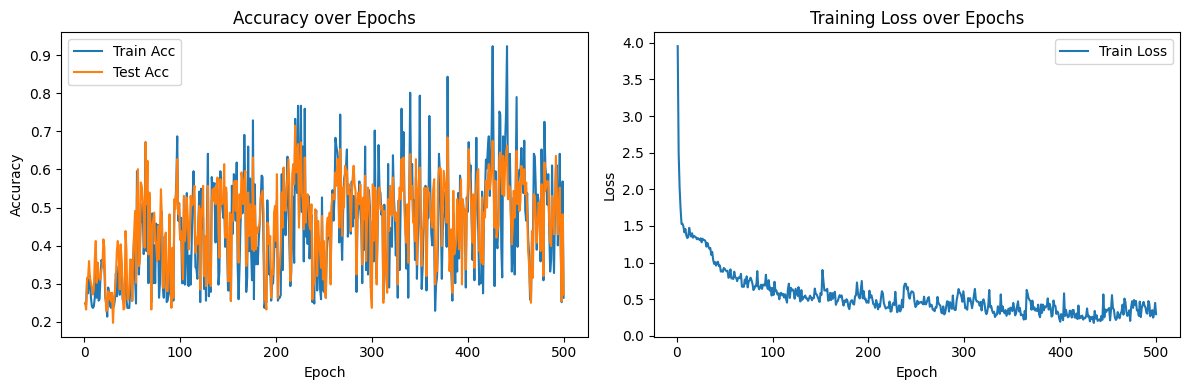

In [147]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm, trange
import matplotlib.pyplot as plt

# 1. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Instantiate Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EEGGraphConvNet(reduced_sensors=False, sfreq=250).to(device)

# 3. Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# 4. Train Function
def train_model(model, train_loader):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# 5. Evaluate Function
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return acc

# 6. Training Loop with Progress Bar and Metrics Logging
num_epochs = 500
best_test_acc = 0.0
best_epoch = 0

train_losses = []
train_accuracies = []
test_accuracies = []

epoch_bar = trange(1, num_epochs + 1, desc="Epochs", leave=True)

for epoch in epoch_bar:
    train_loss = train_model(model, train_loader)
    train_acc = evaluate_model(model, train_loader)
    test_acc = evaluate_model(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch

    epoch_bar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Train Acc': f'{train_acc:.4f}',
        'Test Acc': f'{test_acc:.4f}',
        'Best Test Acc': f'{best_test_acc:.4f} (Epoch {best_epoch})'
    })

print(f"\n✅ Training Complete! Best Test Accuracy: {best_test_acc:.4f} at Epoch {best_epoch}")

# 7. Optional: Plot Learning Curves
def plot_learning_curves(train_losses, train_accuracies, test_accuracies):
    epochs = list(range(1, len(train_losses) + 1))

    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_accuracies, label='Train Acc')
    plt.plot(epochs, test_accuracies, label='Test Acc')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy over Epochs")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss over Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_learning_curves(train_losses, train_accuracies, test_accuracies)